# Feature detection

## Harris Corner detection

As always we start with the imports

In [121]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

To start, we will use the same checkerboard image as earlier.

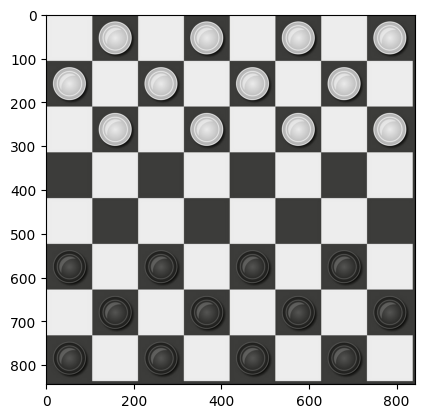

In [122]:
img = cv2.imread('checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2a
Fill in the missing code in the next block. We would like to detect the corners of the image using the OpenCV function [`cv2.cornerHarris`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345). Afterwards we want to draw the location of the detected corners on the image and display it.

[[ 3.0939684e+07  3.0939684e+07  3.0977722e+07 ... -3.5283600e+01
  -3.5521603e+01 -3.5521603e+01]
 [ 3.0939684e+07  3.0939684e+07  3.0977722e+07 ... -3.5283600e+01
  -3.5521603e+01 -3.5521603e+01]
 [ 3.0785192e+07  3.0785192e+07  3.0823908e+07 ... -3.5283600e+01
  -3.5521603e+01 -3.5521603e+01]
 ...
 [-6.7568420e+01 -6.7568420e+01 -6.7568420e+01 ...  5.6873019e+05
   3.0351816e+05  1.1008668e+05]
 [-6.7897621e+01 -6.7897621e+01 -6.7897621e+01 ...  7.2656406e+04
   4.2657141e+04  1.4988943e+04]
 [-6.7897621e+01 -6.7897621e+01 -6.7897621e+01 ...  4.0580647e+03
   3.0729360e+03  2.1326211e+03]]


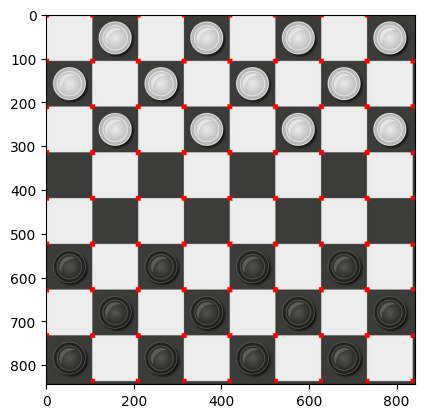

In [123]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

gray = np.float32(gray) # typicla conversion

### Insert Harris Corner detector here ###
# dst = cv2.cornerHarris(src, blockSize (size of corner), ksize, k (0.04-0.06), dst=None, borderType=cv2.BORDER_DEFAULT) DOCS
corners = cv2.cornerHarris(gray, blockSize=10, ksize=3, k=0.04)
print(corners)

### Draw the detected corners in the original image here ###

# threshold: keep only strong responses
img[corners > 0.01 * corners.max()] = [255, 0, 0]  # mark corners red


# Display image
plt.imshow(img)

## Shi-Tomasi
Next we will try the Shi-Tomasi feature detection method. In OpenCV, that method is implemented as [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541). 
Let's start with a different image this time.

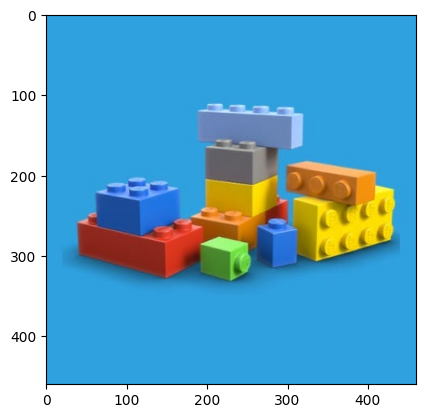

In [124]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2b
Just like the previous exercise, detect the corners of the image by inserting the missing code, this time using the Shi-Tomasi (good features to track) method. Draw the detected corners on the image. Check the documentation of the function for help.

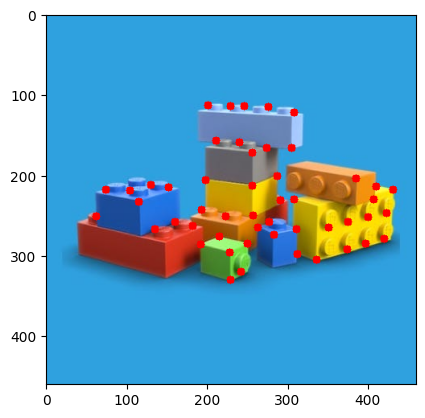

In [125]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

### Insert goodFeaturesToTrack detector here ###
feats = cv2.goodFeaturesToTrack(gray, maxCorners=50, qualityLevel=0.01, minDistance=15) # 0.01 is qualitylevel from 0 to 1.
#print(feats)

### Draw the detected corners in the original image here ###
if feats is not None:
    feats = np.int16(feats)
    for f in feats:
        x, y = f.ravel()
        cv2.circle(img, (x, y), 5, (255, 0, 0), -1) # -1 to fill in
else:
    print("Still no corners — try lowering qualityLevel further or check minDistance")

# Display image
plt.imshow(img)

### Exercise 2c
Do a Harris corner detection on the same Lego image and compare the result with the Shi-Tomasi image.

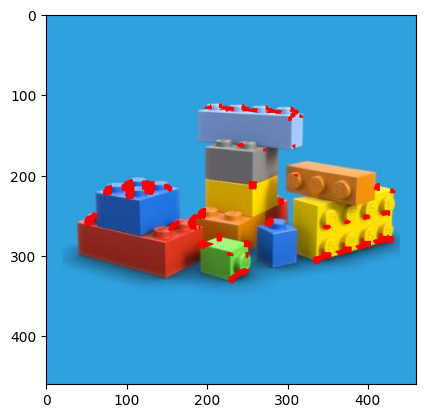

In [134]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

harris_lego_corners = cv2.cornerHarris(gray, blockSize=10, ksize=1, k=0.05)

img[harris_lego_corners > 0.05 * harris_lego_corners.max()] = [255, 0, 0]  # mark corners red

# Display image
plt.imshow(img)